In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip '/content/drive/MyDrive/Group F.zip'

Archive:  /content/drive/MyDrive/Group F.zip
   creating: Group F/
   creating: Group F/Daad_End/
  inflating: Group F/Daad_End/AHCR_00001_Daad_End_32.jpg  
  inflating: Group F/Daad_End/AHCR_00001_Daad_End_33.jpg  
  inflating: Group F/Daad_End/AHCR_00001_Daad_End_40.jpg  
  inflating: Group F/Daad_End/AHCR_00001_Daad_End_41.jpg  
  inflating: Group F/Daad_End/AHCR_00002_Daad_End_32.jpg  
  inflating: Group F/Daad_End/AHCR_00002_Daad_End_33.jpg  
  inflating: Group F/Daad_End/AHCR_00002_Daad_End_40.jpg  
  inflating: Group F/Daad_End/AHCR_00002_Daad_End_41.jpg  
  inflating: Group F/Daad_End/AHCR_00003_Daad_End_32.jpg  
  inflating: Group F/Daad_End/AHCR_00003_Daad_End_33.jpg  
  inflating: Group F/Daad_End/AHCR_00003_Daad_End_40.jpg  
  inflating: Group F/Daad_End/AHCR_00003_Daad_End_41.jpg  
  inflating: Group F/Daad_End/AHCR_00004_Daad_End_32.jpg  
  inflating: Group F/Daad_End/AHCR_00004_Daad_End_33.jpg  
  inflating: Group F/Daad_End/AHCR_00004_Daad_End_40.jpg  
  inflating: Grou

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

img_width, img_height = 150, 150
data_dir = "/content/Group F"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))

    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path): 
            for img_file in os.listdir(group_path):  
                img_path = os.path.join(group_path, img_file)
                try:
                    img = tf.keras.preprocessing.image.load_img(
                        img_path, target_size=(img_width, img_height), color_mode='grayscale'
                    )
                    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                    images.append(img_array)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {img_file} in {group_name}: {e}")

    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

if len(images) == 0:
    raise ValueError("No images were loaded. Check the data directory and file paths.")

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(f"Training samples: {x_train.shape[0]}, Testing samples: {x_test.shape[0]}")
print(f"Number of classes: {num_classes}")


Training samples: 2933, Testing samples: 734
Number of classes: 8


In [5]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [6]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


184/184 ━━━━━━━━━━━━━━━━━━━━ 25s 83ms/step - accuracy: 0.1159 - loss: 2.1658 - val_accuracy: 0.1104 - val_loss: 2.0801
Epoch 2/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.1245 - loss: 2.0793 - val_accuracy: 0.1172 - val_loss: 2.0811
Epoch 3/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.1234 - loss: 2.0793 - val_accuracy: 0.1104 - val_loss: 2.0817
Epoch 4/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.1222 - loss: 2.0791 - val_accuracy: 0.1090 - val_loss: 2.0832
Epoch 5/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.1290 - loss: 2.0884 - val_accuracy: 0.1185 - val_loss: 2.0749
Epoch 6/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.1639 - loss: 2.0126 - val_accuracy: 0.3501 - val_loss: 1.6082
Epoch 7/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.3468 - loss: 1.6643 - val_accuracy: 0.5763 - val_loss: 1.2219
Epoch 8/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.4949 - loss: 1.3501 - val_accuracy: 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9133 - loss: 0.2866
Train Accuracy: 85.44%
Test Accuracy: 91.83%


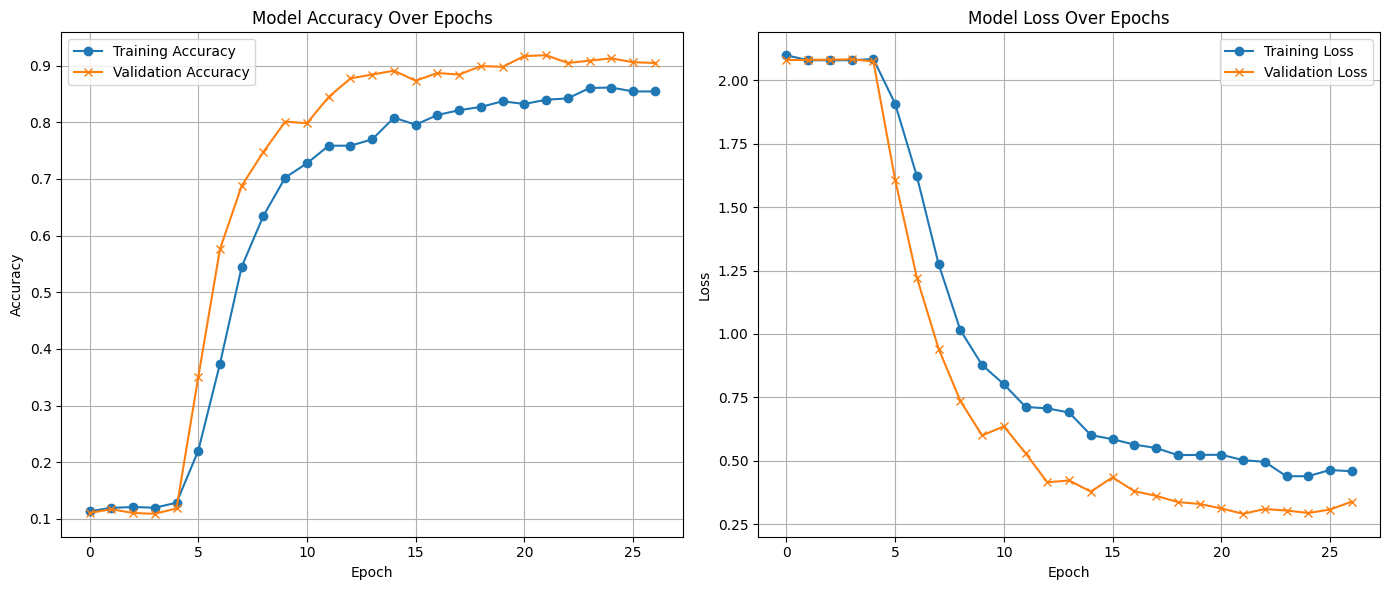

In [8]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


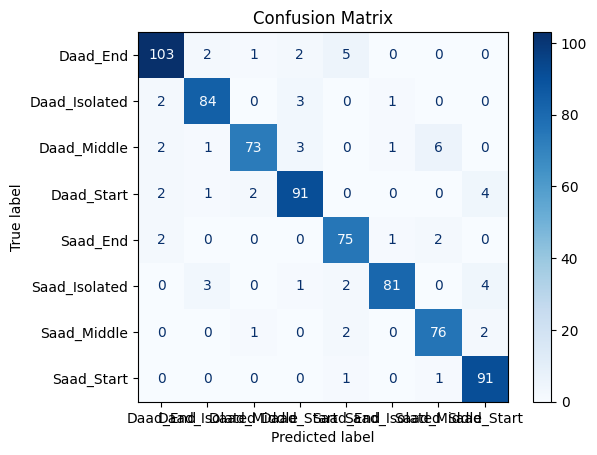

Number of incorrect predictions: 60


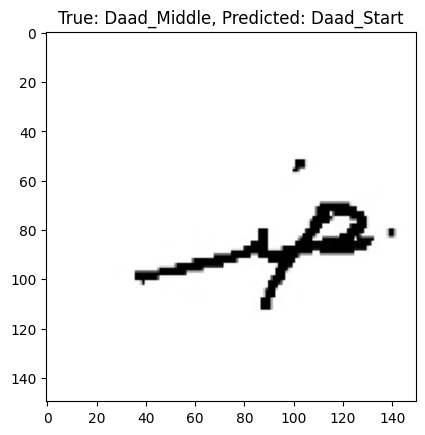

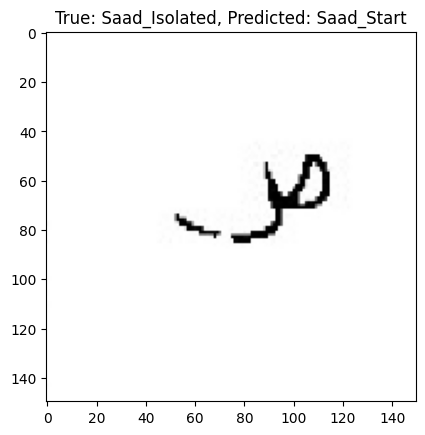

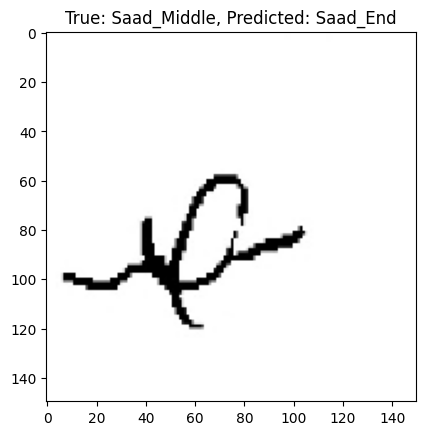

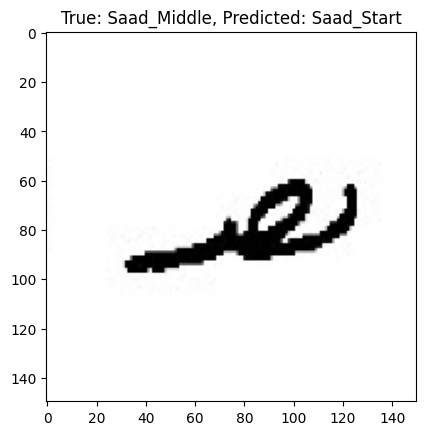

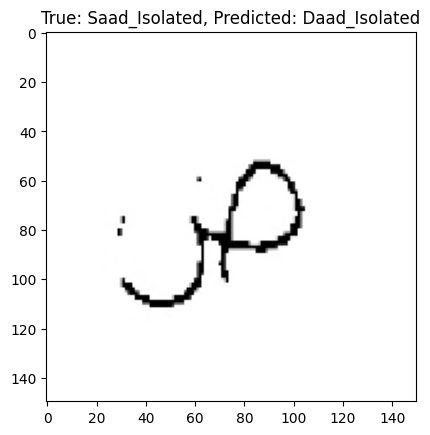

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### reduce dropout and epochs 

In [11]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [12]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=28,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/28


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - accuracy: 0.1345 - loss: 2.1758 - val_accuracy: 0.1608 - val_loss: 2.0400
Epoch 2/28
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.2506 - loss: 1.9087 - val_accuracy: 0.4251 - val_loss: 1.4482
Epoch 3/28
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.4121 - loss: 1.5261 - val_accuracy: 0.6689 - val_loss: 0.9656
Epoch 4/28
184/184 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - accuracy: 0.6123 - loss: 1.0935 - val_accuracy: 0.7902 - val_loss: 0.6337
Epoch 5/28
184/184 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.7277 - loss: 0.8146 - val_accuracy: 0.8215 - val_loss: 0.5129
Epoch 6/28
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.7741 - loss: 0.6451 - val_accuracy: 0.8774 - val_loss: 0.4143
Epoch 7/28
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.7999 - loss: 0.5890 - val_accuracy: 0.8842 - val_loss: 0.3708
Epoch 8/28
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.8206 - loss: 0.5526 - val_accuracy: 0

In [18]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9256 - loss: 0.2272
Train Accuracy: 92.70%
Test Accuracy: 92.64%


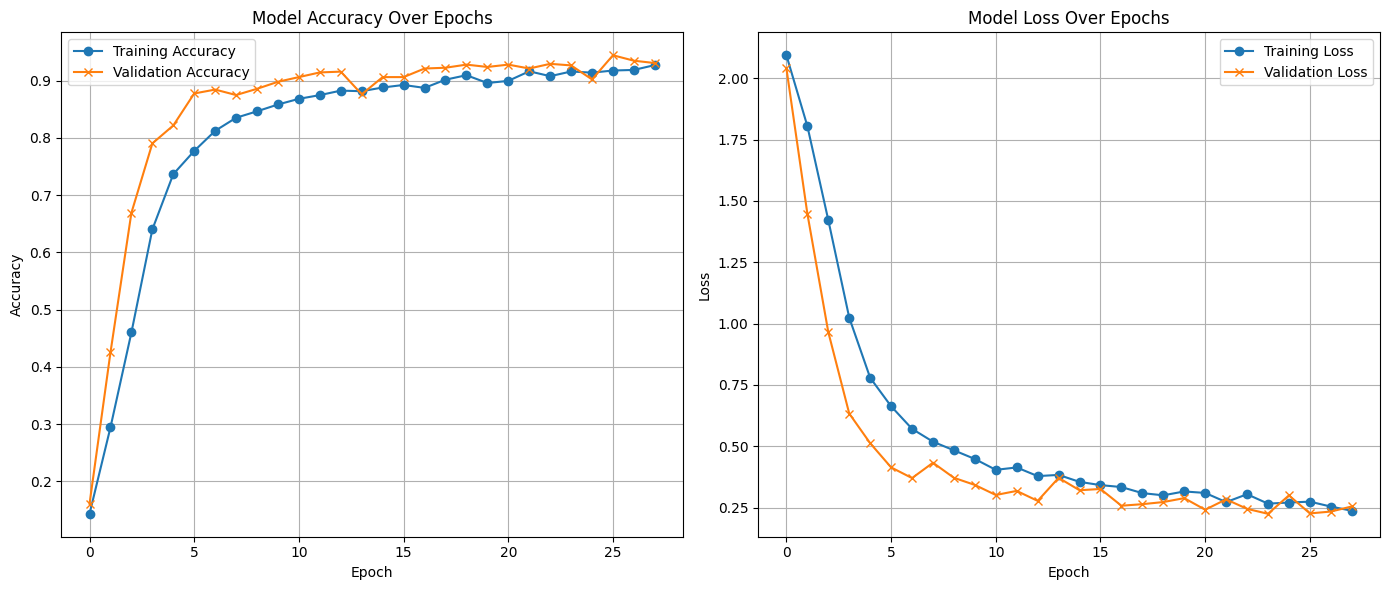

In [15]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


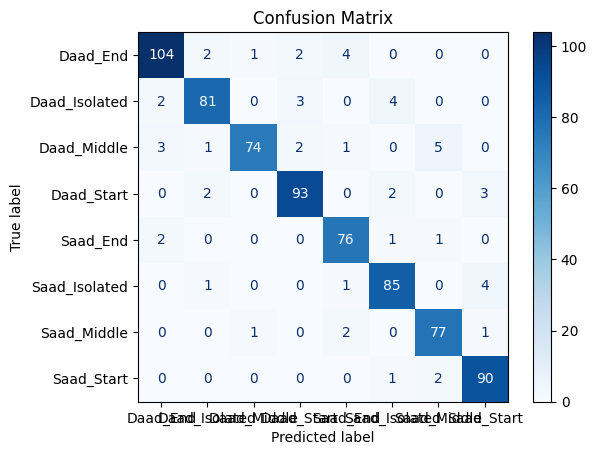

Number of incorrect predictions: 54


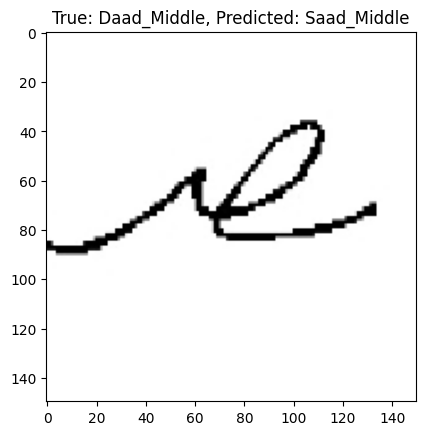

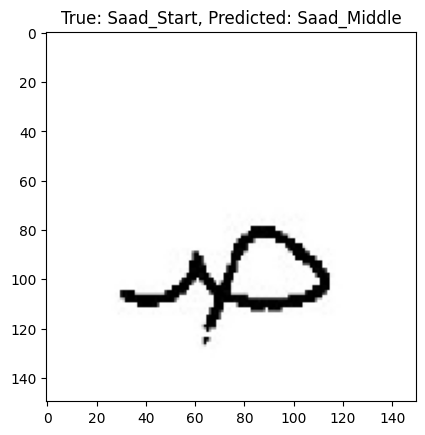

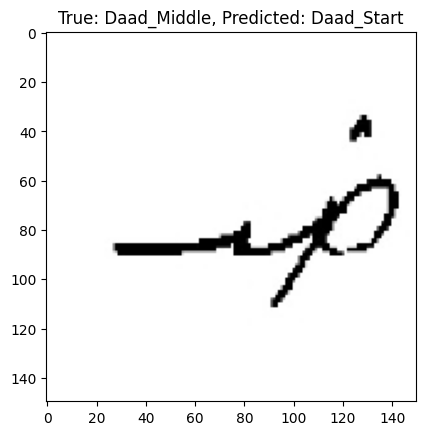

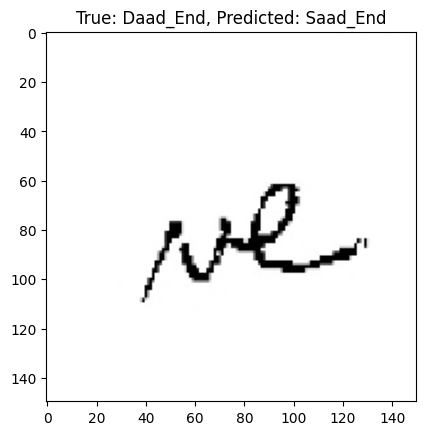

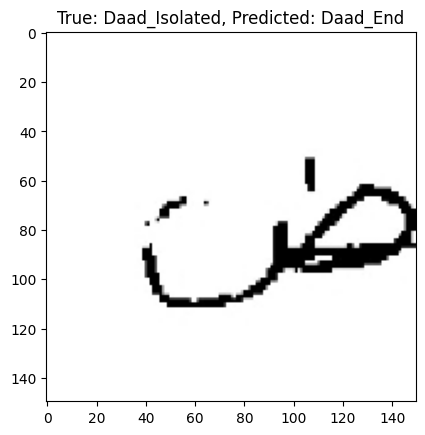

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


In [19]:
model.save("GrpF.keras")